In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score

In [ ]:
df=pd.read_csv('/content/student_placement_logistic.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentId           600 non-null    int64  
 1   Placed              600 non-null    int64  
 2   Age                 585 non-null    float64
 3   CGPA                585 non-null    float64
 4   Internships         585 non-null    float64
 5   Projects            585 non-null    float64
 6   AptitudeScore       586 non-null    float64
 7   CommunicationScore  585 non-null    float64
 8   Attendance          585 non-null    float64
 9   Backlogs            585 non-null    float64
 10  Branch              591 non-null    object 
 11  Gender              591 non-null    object 
 12  TrainingCompleted   591 non-null    object 
dtypes: float64(8), int64(2), object(3)
memory usage: 61.1+ KB


In [ ]:
df.head()

,StudentId,Placed,Age,CGPA,Internships,Projects,AptitudeScore,CommunicationScore,Attendance,Backlogs,Branch,Gender,TrainingCompleted
0,3001,0,22.0,7.72,1.0,1.0,71.3,55.0,87.0,2.0,Civil,Male,Yes
1,3002,1,24.8,8.51,0.0,1.0,63.4,70.2,82.2,0.0,Civil,Male,Yes
2,3003,1,21.6,8.84,2.0,3.0,71.4,76.4,90.7,1.0,ME,Male,Yes
3,3004,1,21.2,7.60,0.0,5.0,71.7,89.7,74.9,0.0,Civil,Female,No
4,3005,1,23.0,6.91,3.0,4.0,62.0,74.7,97.5,0.0,Civil,Female,Yes


In [ ]:
df.shape

(600, 13)

In [ ]:
df.describe()

,StudentId,Placed,Age,CGPA,Internships,Projects,AptitudeScore,CommunicationScore,Attendance,Backlogs
count,600.000000,600.000000,585.000000,585.000000,585.000000,585.000000,586.000000,585.000000,585.000000,585.000000
mean,3300.500000,0.500000,21.524444,7.533248,1.249573,2.220513,68.587884,70.259145,82.024103,0.692308
std,173.349358,0.500417,1.263394,0.974943,1.152397,1.463338,15.606862,14.699908,8.892290,0.852691
min,3001.000000,0.000000,18.000000,5.000000,0.000000,0.000000,25.000000,25.500000,59.000000,0.000000
25%,3150.750000,0.000000,20.600000,6.820000,0.000000,1.000000,58.625000,61.500000,75.800000,0.000000
50%,3300.500000,0.500000,21.500000,7.520000,1.000000,2.000000,68.400000,70.500000,81.500000,0.000000
75%,3450.250000,1.000000,22.500000,8.130000,2.000000,3.000000,76.775000,78.500000,88.900000,1.000000
max,3600.000000,1.000000,24.800000,10.000000,5.000000,8.000000,150.000000,150.000000,100.000000,5.000000


In [ ]:
#indentifgy duplicate records
print("number of duplicates recodrs :",df.duplicated().sum())

number of duplicates recodrs : 0


In [ ]:
#indentifuy null values
df.isnull().sum()

,0
StudentId,0
Placed,0
Age,15
CGPA,15
Internships,15
Projects,15
AptitudeScore,14
CommunicationScore,15
Attendance,15
Backlogs,15


In [ ]:
# fill the missing values

df['Age'].fillna(df['Age'].mean(), inplace=True)
df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)
df['Internships'].fillna(df['Internships'].mean(), inplace=True)
df['Projects'].fillna(df['Projects'].mean(), inplace=True)
df['AptitudeScore'].fillna(df['AptitudeScore'].mean(), inplace=True)
df['CommunicationScore'].fillna(df['CommunicationScore'].mean(), inplace=True)
df['Attendance'].fillna(df['Attendance'].mean(), inplace=True)
df['Backlogs'].fillna(df['Backlogs'].mean(), inplace=True)

df['Branch'].fillna(df['Branch'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['TrainingCompleted'].fillna(df['TrainingCompleted'].mode()[0], inplace=True)

/tmp/ipykernel_2406/227337487.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_2406/227337487.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
#indentifuy null values
df.isnull().sum()

,0
StudentId,0
Placed,0
Age,0
CGPA,0
Internships,0
Projects,0
AptitudeScore,0
CommunicationScore,0
Attendance,0
Backlogs,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
# LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'].astype(str))
df['TrainingCompleted'] = le.fit_transform(df['TrainingCompleted'].astype(str))

In [ ]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['Branch'])

In [ ]:
df.head()

,StudentId,Placed,Age,CGPA,Internships,Projects,AptitudeScore,CommunicationScore,Attendance,Backlogs,Gender,TrainingCompleted,Branch_0,Branch_1,Branch_2,Branch_3,Branch_4,Branch_5
0,3001,0,22.0,7.72,1.0,1.0,71.3,55.0,87.0,2.0,2,2,False,False,True,False,False,False
1,3002,1,24.8,8.51,0.0,1.0,63.4,70.2,82.2,0.0,2,2,False,False,True,False,False,False
2,3003,1,21.6,8.84,2.0,3.0,71.4,76.4,90.7,1.0,2,2,False,False,False,False,False,True
3,3004,1,21.2,7.60,0.0,5.0,71.7,89.7,74.9,0.0,1,1,False,False,True,False,False,False
4,3005,1,23.0,6.91,3.0,4.0,62.0,74.7,97.5,0.0,1,2,False,False,True,False,False,False


In [ ]:
# create new Total Experience
df['Total_Experience'] = df['Internships'] + df['Projects']

print(df[['Internships', 'Projects', 'Total_Experience']].head())

   Internships  Projects  Total_Experience
0          1.0       1.0               2.0
1          0.0       1.0               1.0
2          2.0       3.0               5.0
3          0.0       5.0               5.0
4          3.0       4.0               7.0


In [ ]:
# create new feature 'HasExperience'
df['HasExperience'] = 0
df.loc[df['Total_Experience'] > 0, 'HasExperience'] = 1

print(df[['Total_Experience', 'HasExperience']].head(10))

   Total_Experience  HasExperience
0               2.0              1
1               1.0              1
2               5.0              1
3               5.0              1
4               7.0              1
5               7.0              1
6               2.0              1
7               5.0              1
8               1.0              1
9               3.0              1


In [ ]:
# outlier detection
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 17.650000000000002
Upper Bound: 25.249999999999996


In [ ]:
#print outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
     StudentId  Placed  Age   CGPA  Internships  Projects  AptitudeScore  \
50        3051       0  0.0   7.98          0.0       0.0           57.9   
52        3053       1  0.0  10.00          1.0       1.0           55.9   
56        3057       0  0.0   7.78          2.0       0.0           45.2   
119       3120       0  0.0   6.21          4.0       0.0           55.1   
255       3256       1  0.0   7.77          4.0       1.0           76.2   
258       3259       0  0.0   5.82          0.0       3.0           37.5   
313       3314       1  0.0   6.51          1.0       4.0           92.6   
384       3385       0  0.0   8.48          0.0       1.0           65.3   
413       3414       1  0.0   9.67          3.0       4.0           32.6   
430       3431       1  0.0   7.06          4.0       2.0           55.2   
439       3440       0  0.0   7.16          1.0       2.0           55.9   
454       3455       1  0.0   9.81          0.0       0.0           57.9   
45

In [ ]:
# remove outliers
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (585, 20)


In [ ]:
# outlier detection for AptitudeScore
Q1 = df['AptitudeScore'].quantile(0.25)
Q3 = df['AptitudeScore'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 30.69999999999999
Upper Bound: 104.30000000000001


In [ ]:
#print outliers
outliers = df[(df['AptitudeScore'] < lower_bound)|(df['AptitudeScore'] > upper_bound)]
print("Outliers:")
print(outliers)

Outliers:
     StudentId  Placed   Age  CGPA  Internships  Projects  AptitudeScore  \
21        3022       0  21.6  6.82          0.0       0.0            0.0   
47        3048       0  23.6  5.94          0.0       4.0            0.0   
67        3068       0  22.8  7.81          0.0       1.0            0.0   
82        3083       1  23.6  7.83          0.0       2.0            0.0   
96        3097       0  21.8  5.04          1.0       0.0          150.0   
144       3145       0  20.3  8.03          0.0       0.0            0.0   
259       3260       0  20.6  0.00          1.0       1.0            0.0   
263       3264       1  22.1  6.59          2.0       3.0          150.0   
279       3280       1  21.7  7.71          0.0       3.0            0.0   
292       3293       1  20.3  9.69          0.0       4.0          150.0   
335       3336       0  21.3  6.91          4.0       3.0           25.0   
336       3337       1  20.0  7.35          1.0       5.0            0.0   
33

In [ ]:
# remove outliers
df = df[(df['AptitudeScore'] >= lower_bound)&(df['AptitudeScore'] <= upper_bound)]
print("dataset shape after removing outliers:", df.shape)

dataset shape after removing outliers: (565, 20)


In [ ]:
# identify x and y
x = df.drop(['Placed'], axis=1)
y = df['Placed']

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data set into training and testing dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

cols_to_scale = [
    'Age',
    'CGPA',
    'Internships',
    'Projects',
    'AptitudeScore',
    'CommunicationScore',
    'Attendance',
    'Backlogs',
    'Total_Experience']

x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

In [ ]:
print("First 5 rows of x_train data:")
print(x_train.head())

First 5 rows of x_train data:
     StudentId       Age      CGPA  Internships  Projects  AptitudeScore  \
352       3353  2.075678  0.807419    -1.076353 -0.801612       1.327685   
126       3127 -0.165771 -0.356285     1.567731  2.559508      -0.196078   
221       3222 -0.646081  1.005778     0.686370 -0.801612      -1.082498   
0         3001  0.394591  0.218955    -0.194991 -0.801612       0.228817   
527       3528  0.234488 -0.395957    -1.076353 -0.129388       0.404636   

     CommunicationScore  Attendance  Backlogs  Gender  TrainingCompleted  \
352           -0.154290    0.729087 -0.807174       2                  2   
126            0.316623    0.642760 -0.807174       1                  1   
221           -0.225474    1.182305 -0.807174       1                  1   
0             -0.745669    0.441329  1.501956       2                  2   
527           -1.030407    0.369390 -0.807174       1                  2   

     Branch_0  Branch_1  Branch_2  Branch_3  Branch_4  B

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# predictions on test data
y_pred = model.predict(x_test)

In [ ]:
train_accuracy=model.score(x_train,y_train)
test_accuracy=model.score(x_test,y_test)
print("Train Accuracy:",train_accuracy)
print("Test Accuracy:",test_accuracy)

Train Accuracy: 0.7411504424778761
Test Accuracy: 0.8053097345132744


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
TP,FN,FP,TN = cm.ravel()
print("\nConfusion Matrix")
print(cm)
print("\nTrue Positive (TP):",TP)
print("True Negative (TN):",TN)

print("False Positive (FP):",FP)
print("False Negative (FN):",FN)


Confusion Matrix
[[48 12]
 [10 43]]

True Positive (TP): 48
True Negative (TN): 43
False Positive (FP): 10
False Negative (FN): 12


In [ ]:
#printing roc_auc_score
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8723270440251573


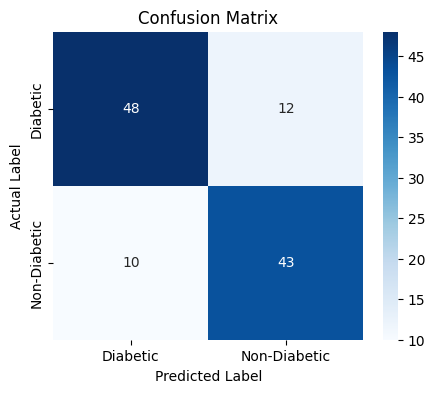

In [ ]:
#display confusition matrix
cm_display = [[TP, FN],
[FP, TN]]
plt.figure(figsize=(5,4))
sns.heatmap(cm_display,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['Diabetic', 'Non-Diabetic'],
yticklabels=['Diabetic', 'Non-Diabetic'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#print classification report
class_report = classification_report(y_test,y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        60
           1       0.78      0.81      0.80        53

    accuracy                           0.81       113
   macro avg       0.80      0.81      0.80       113
weighted avg       0.81      0.81      0.81       113



In [ ]:
#print aur_roc_curve
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
auc=roc_auc_score(y_test,y_pred)



AUC Score : 0.8723270440251573


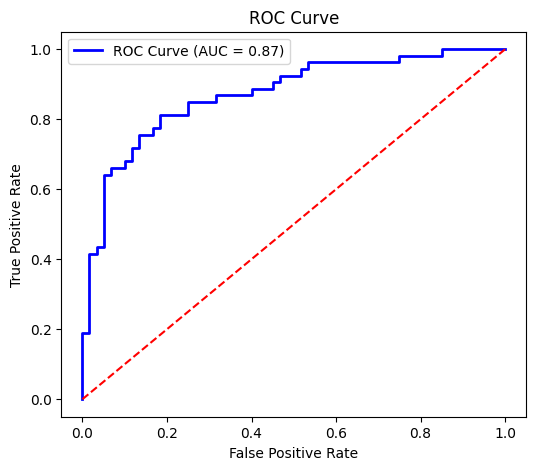

In [ ]:
#display roc curve
y_prob = model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print("\nAUC Score :",auc_score)
plt.figure(figsize=(6,5))
plt.plot(fpr,
tpr,
color='blue',
lw=2,
label='ROC Curve (AUC = %0.2f)' % auc_score)

plt.plot([0,1],[0,1],
color='red',
linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()